In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_hdf("data/full_Finallevel_nugen_22852-22860.h5")

In [4]:
print(df["I3MCWeightDict_InIceNeutrinoType"])

0       -14.0
1        14.0
2        14.0
3        14.0
4        14.0
         ... 
78206    16.0
78207    16.0
78208    16.0
78209   -16.0
78210    16.0
Name: I3MCWeightDict_InIceNeutrinoType, Length: 1453648, dtype: float64


In [5]:
interactions = df['I3MCWeightDict_InteractionType']
interactions.value_counts()
is_cc = interactions == 1.0
is_nc = interactions == 2.0

In [6]:
flavor = df["I3MCWeightDict_InIceNeutrinoType"]
tau_neutrino = abs(flavor) == 16
print(tau_neutrino.sum())

396246


In [7]:
electron_neutrino = abs(flavor) == 12
print(electron_neutrino.sum())
muon_neutrino = abs(flavor) == 14

664420


In [8]:
cc_muon_neutrino = (abs(flavor) == 14) & (is_cc)
print(cc_muon_neutrino.sum())

169936


In [9]:
ele_neu = flavor == 12
anti_ele_neu = flavor == -12
print(ele_neu.sum())
print(anti_ele_neu.sum())

539186
125234


In [10]:
mu_neu = flavor == 14
anti_mu_neu = flavor == -14
print(mu_neu.sum())
print(anti_mu_neu.sum())

215879
177103


In [11]:
tau_neu = flavor == 16
anti_tau_neu = flavor == -16
print(tau_neu.sum())
print(anti_tau_neu.sum())

202783
193463


In [12]:
energy = df["I3MCWeightDict_PrimaryNeutrinoEnergy"]
energy_cut = (energy >= 1e4) & (energy <= 5e4)

In [13]:
bjx = df["I3MCWeightDict_BjorkenX"]
print(bjx)

0        0.020612
1        0.110922
2        0.136173
3        0.054060
4        0.362498
           ...   
78206    0.000287
78207    0.013650
78208    0.000728
78209    0.000717
78210    0.008953
Name: I3MCWeightDict_BjorkenX, Length: 1453648, dtype: float64


In [15]:
bjx_cols = [col for col in df.columns if "weight" in col.lower()]
print(bjx_cols)

['I3MCWeightDict_Run', 'I3MCWeightDict_Event', 'I3MCWeightDict_SubEvent', 'I3MCWeightDict_SubEventStream', 'I3MCWeightDict_exists', 'I3MCWeightDict_BjorkenX', 'I3MCWeightDict_BjorkenY', 'I3MCWeightDict_CylinderHeight', 'I3MCWeightDict_CylinderRadius', 'I3MCWeightDict_DirectionWeight', 'I3MCWeightDict_EnergyLost', 'I3MCWeightDict_ImpactParam', 'I3MCWeightDict_InIceNeutrinoEnergy', 'I3MCWeightDict_InIceNeutrinoType', 'I3MCWeightDict_InjectionAreaCGS', 'I3MCWeightDict_InjectionOrigin_x', 'I3MCWeightDict_InjectionOrigin_y', 'I3MCWeightDict_InjectionOrigin_z', 'I3MCWeightDict_InteractionColumnDepthCGS', 'I3MCWeightDict_InteractionPositionWeight', 'I3MCWeightDict_InteractionType', 'I3MCWeightDict_InteractionTypeWeight', 'I3MCWeightDict_InteractionWeight', 'I3MCWeightDict_InteractionXsectionCGS', 'I3MCWeightDict_LengthInVolume', 'I3MCWeightDict_MaxAzimuth', 'I3MCWeightDict_MaxEnergyLog', 'I3MCWeightDict_MaxZenith', 'I3MCWeightDict_MinAzimuth', 'I3MCWeightDict_MinEnergyLog', 'I3MCWeightDict_Mi

In [16]:
bjy = df["I3MCWeightDict_BjorkenY"]
print(bjy)

0        0.870789
1        0.655197
2        0.846402
3        0.585843
4        0.784344
           ...   
78206    0.542372
78207    0.011737
78208    0.567197
78209    0.562068
78210    0.127327
Name: I3MCWeightDict_BjorkenY, Length: 1453648, dtype: float64


In [17]:
mu_cc = bjy[energy_cut & mu_neu & is_cc]
mu_nc = bjy[energy_cut & mu_neu & is_nc]
anti_mu_cc = bjy[energy_cut & anti_mu_neu & is_cc]
anti_mu_nc = bjy[energy_cut & anti_mu_neu & is_nc]

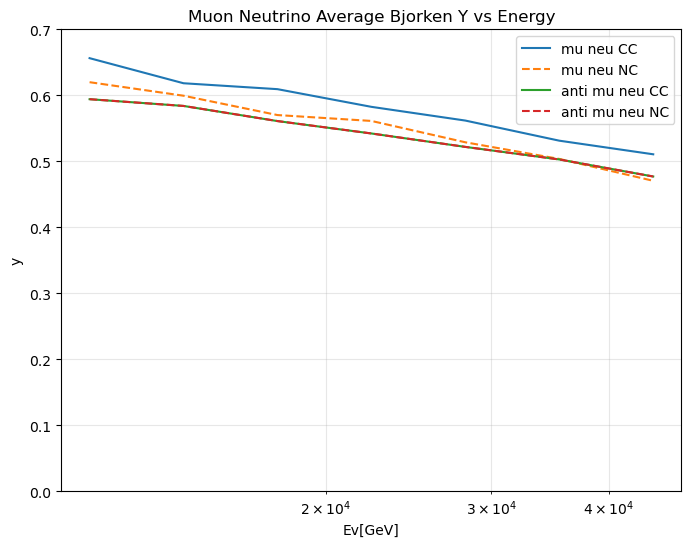

In [18]:
energy_bins = np.logspace(4, np.log10(5e4), 8)
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

def avg_y_in_bins(mask):
    avg_y = []

    for low, high in zip(energy_bins[:-1], energy_bins[1:]):
        bin_mask = mask & (energy >= low) & (energy < high)
        avg_y.append(bjy[bin_mask].mean())

    return np.array(avg_y)

mu_neu_cc_avg = avg_y_in_bins(mu_neu & is_cc)
mu_neu_nc_avg = avg_y_in_bins(mu_neu & is_nc)

anti_mu_neu_cc_avg = avg_y_in_bins(anti_mu_neu & is_cc)
anti_mu_neu_nc_avg = avg_y_in_bins(anti_mu_neu & is_nc)

plt.figure(figsize=(8,6))

plt.plot(energy_centers, mu_neu_cc_avg, linestyle="-", label="mu neu CC")
plt.plot(energy_centers, mu_neu_nc_avg, linestyle="--", label="mu neu NC")

plt.plot(energy_centers, anti_mu_neu_cc_avg, linestyle="-", label="anti mu neu CC")
plt.plot(energy_centers, anti_mu_neu_cc_avg, linestyle="--", label="anti mu neu NC")

plt.xscale("log")
plt.xlabel("Ev[GeV]")
plt.ylabel("y")
plt.title("Muon Neutrino Average Bjorken Y vs Energy")

plt.ylim(0, 0.7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

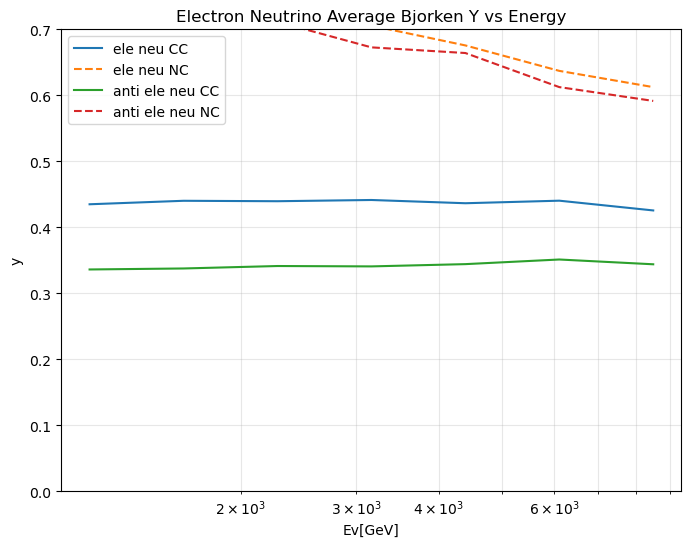

In [19]:
energy_bins = np.logspace(3, np.log10(1e4), 8)
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

def avg_y_in_bins(mask):
    avg_y = []

    for low, high in zip(energy_bins[:-1], energy_bins[1:]):
        bin_mask = mask & (energy >= low) & (energy < high)
        avg_y.append(bjy[bin_mask].mean())

    return np.array(avg_y)

ele_neu_cc_avg = avg_y_in_bins(ele_neu & is_cc)
ele_neu_nc_avg = avg_y_in_bins(ele_neu & is_nc)

anti_ele_neu_cc_avg = avg_y_in_bins(anti_ele_neu & is_cc)
anti_ele_neu_nc_avg = avg_y_in_bins(anti_ele_neu & is_nc)

plt.figure(figsize=(8,6))

plt.plot(energy_centers, ele_neu_cc_avg, linestyle="-", label="ele neu CC")
plt.plot(energy_centers, ele_neu_nc_avg, linestyle="--", label="ele neu NC")

plt.plot(energy_centers, anti_ele_neu_cc_avg, linestyle="-", label="anti ele neu CC")
plt.plot(energy_centers, anti_ele_neu_nc_avg, linestyle="--", label="anti ele neu NC")

plt.xscale("log")
plt.xlabel("Ev[GeV]")
plt.ylabel("y")
plt.title("Electron Neutrino Average Bjorken Y vs Energy")

plt.ylim(0, 0.7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

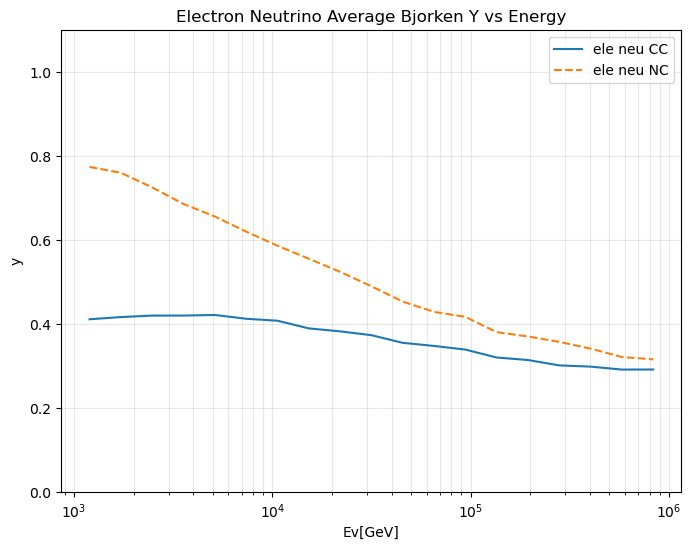

In [20]:
energy_bins = np.logspace(3, np.log10(1e6), 20)
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

def avg_y_in_bins(mask):
    avg_y = []

    for low, high in zip(energy_bins[:-1], energy_bins[1:]):
        bin_mask = mask & (energy >= low) & (energy < high)
        avg_y.append(bjy[bin_mask].mean())

    return np.array(avg_y)

ele_neu_cc_avg = avg_y_in_bins(electron_neutrino & is_cc)
ele_neu_nc_avg = avg_y_in_bins(electron_neutrino & is_nc)

plt.figure(figsize=(8,6))

plt.plot(energy_centers, ele_neu_cc_avg, linestyle="-", label="ele neu CC")
plt.plot(energy_centers, ele_neu_nc_avg, linestyle="--", label="ele neu NC")

plt.xscale("log")
plt.xlabel("Ev[GeV]")
plt.ylabel("y")
plt.title("Electron Neutrino Average Bjorken Y vs Energy")

plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

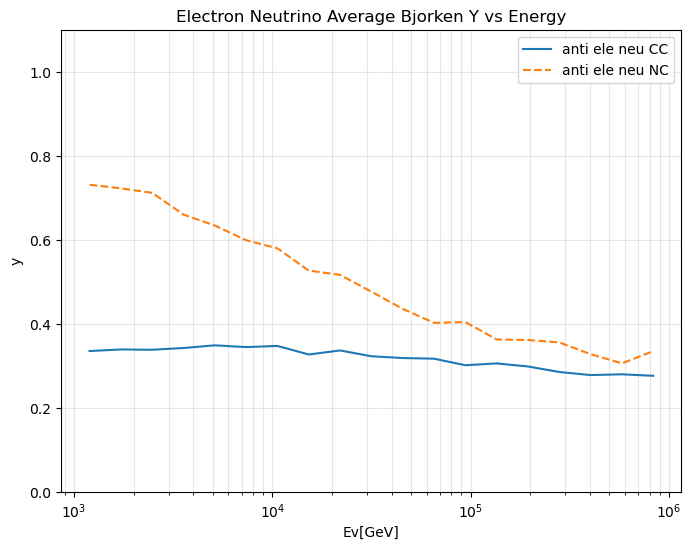

In [21]:
energy_bins = np.logspace(3, np.log10(1e6), 20)
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

def avg_y_in_bins(mask):
    avg_y = []

    for low, high in zip(energy_bins[:-1], energy_bins[1:]):
        bin_mask = mask & (energy >= low) & (energy < high)
        avg_y.append(bjy[bin_mask].mean())

    return np.array(avg_y)

anti_ele_neu_cc_avg = avg_y_in_bins(anti_ele_neu & is_cc)
anti_ele_neu_nc_avg = avg_y_in_bins(anti_ele_neu & is_nc)

plt.figure(figsize=(8,6))

plt.plot(energy_centers, anti_ele_neu_cc_avg, linestyle="-", label="anti ele neu CC")
plt.plot(energy_centers, anti_ele_neu_nc_avg, linestyle="--", label="anti ele neu NC")

plt.xscale("log")
plt.xlabel("Ev[GeV]")
plt.ylabel("y")
plt.title("Electron Neutrino Average Bjorken Y vs Energy")

plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

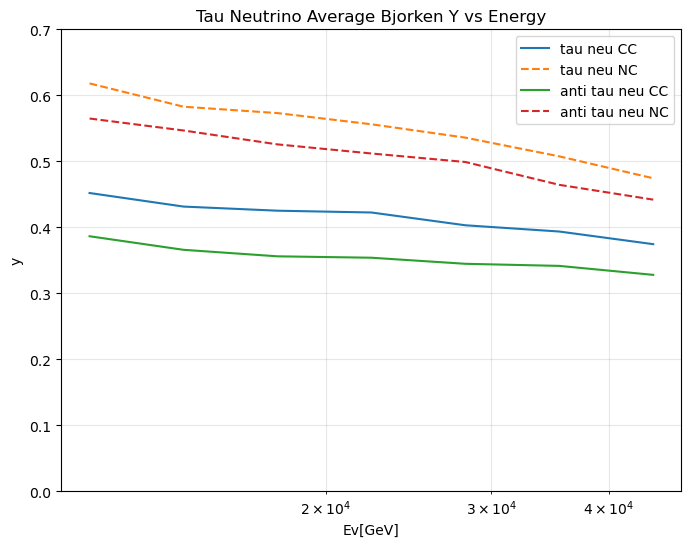

In [22]:
energy_bins = np.logspace(4, np.log10(5e4), 8)
energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

def avg_y_in_bins(mask):
    avg_y = []

    for low, high in zip(energy_bins[:-1], energy_bins[1:]):
        bin_mask = mask & (energy >= low) & (energy < high)
        avg_y.append(bjy[bin_mask].mean())

    return np.array(avg_y)

tau_neu_cc_avg = avg_y_in_bins(tau_neu & is_cc)
tau_neu_nc_avg = avg_y_in_bins(tau_neu & is_nc)

anti_tau_neu_cc_avg = avg_y_in_bins(anti_tau_neu & is_cc)
anti_tau_neu_nc_avg = avg_y_in_bins(anti_tau_neu & is_nc)

plt.figure(figsize=(8,6))

plt.plot(energy_centers, tau_neu_cc_avg, linestyle="-", label="tau neu CC")
plt.plot(energy_centers, tau_neu_nc_avg, linestyle="--", label="tau neu NC")

plt.plot(energy_centers, anti_tau_neu_cc_avg, linestyle="-", label="anti tau neu CC")
plt.plot(energy_centers, anti_tau_neu_nc_avg, linestyle="--", label="anti tau neu NC")

plt.xscale("log")
plt.xlabel("Ev[GeV]")
plt.ylabel("y")
plt.title("Tau Neutrino Average Bjorken Y vs Energy")

plt.ylim(0, 0.7)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [23]:
bx_electron_neutrino = df[electron_neutrino]["I3MCWeightDict_BjorkenX"]
bx_muon_neutrino = df[muon_neutrino]["I3MCWeightDict_BjorkenX"]
bx_tau_neutrino = df[tau_neutrino]["I3MCWeightDict_BjorkenX"]

In [24]:
by_electron_neutrino = df[electron_neutrino]["I3MCWeightDict_BjorkenY"]
by_muon_neutrino = df[muon_neutrino]["I3MCWeightDict_BjorkenY"]
by_cc_muon_neutrino = df[cc_muon_neutrino]["I3MCWeightDict_BjorkenY"]
by_tau_neutrino = df[tau_neutrino]["I3MCWeightDict_BjorkenY"]

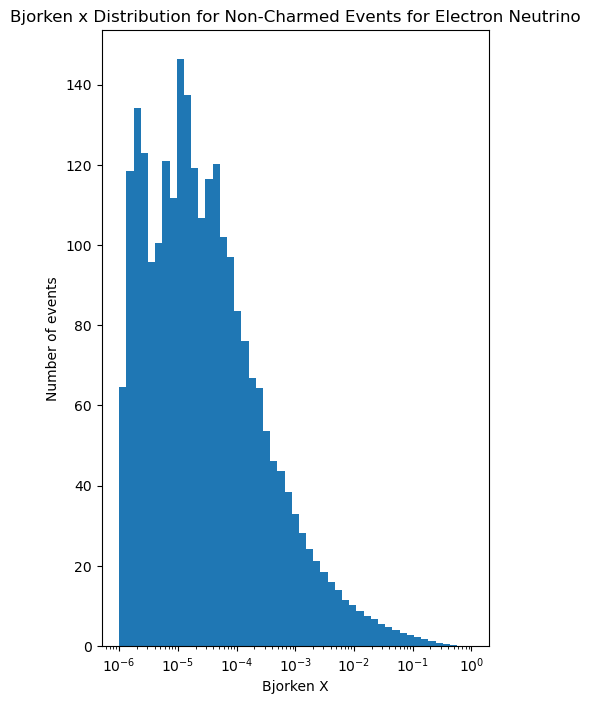

In [25]:
bins = np.logspace(-6, 0, 50)
plt.figure(figsize=(5,8))
plt.hist(bx_electron_neutrino, bins = bins, density = True)
plt.xscale("log")
plt.xlabel("Bjorken X")
plt.ylabel("Number of events")
plt.title("Bjorken x Distribution for Non-Charmed Events for Electron Neutrino")
plt.show()

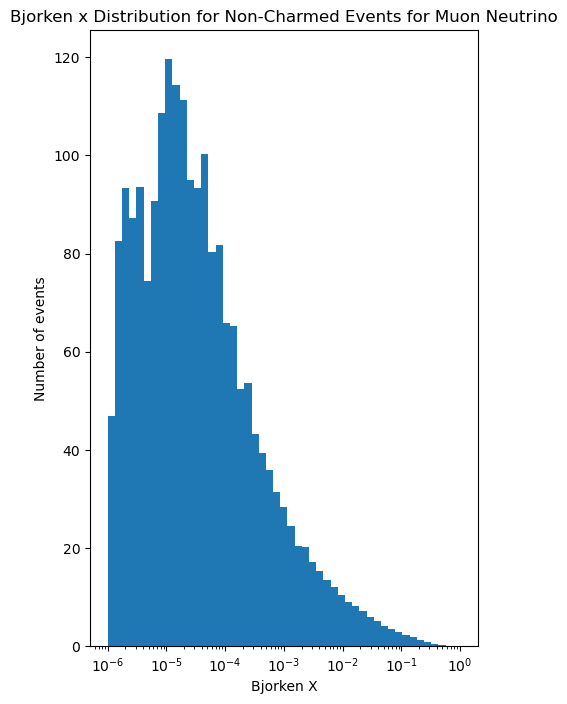

In [26]:
bins = np.logspace(-6, 0, 50)
plt.figure(figsize=(5,8))
plt.hist(bx_muon_neutrino, bins = bins, density = True)
plt.xscale("log")
plt.xlabel("Bjorken X")
plt.ylabel("Number of events")
plt.title("Bjorken x Distribution for Non-Charmed Events for Muon Neutrino")
plt.show()

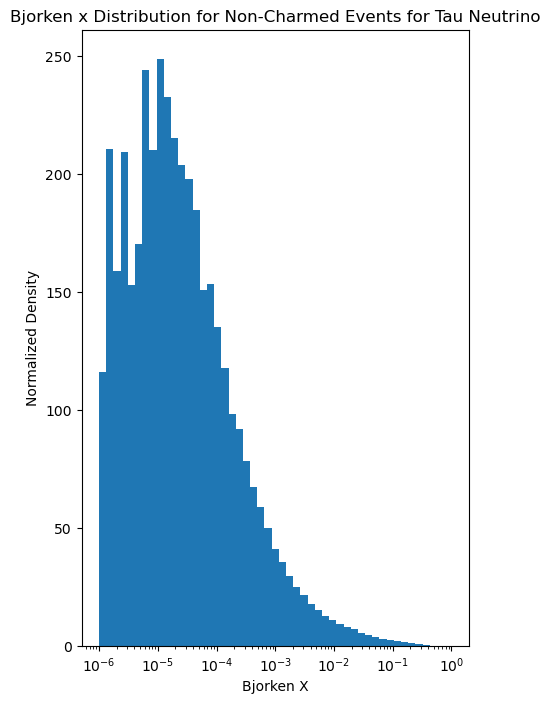

In [27]:
bins = np.logspace(-6, 0, 50)
plt.figure(figsize=(5,8))
plt.hist(bx_tau_neutrino, bins = bins, density = True)
plt.xscale("log")
plt.xlabel("Bjorken X")
plt.ylabel("Normalized Density")
plt.title("Bjorken x Distribution for Non-Charmed Events for Tau Neutrino")
plt.show()

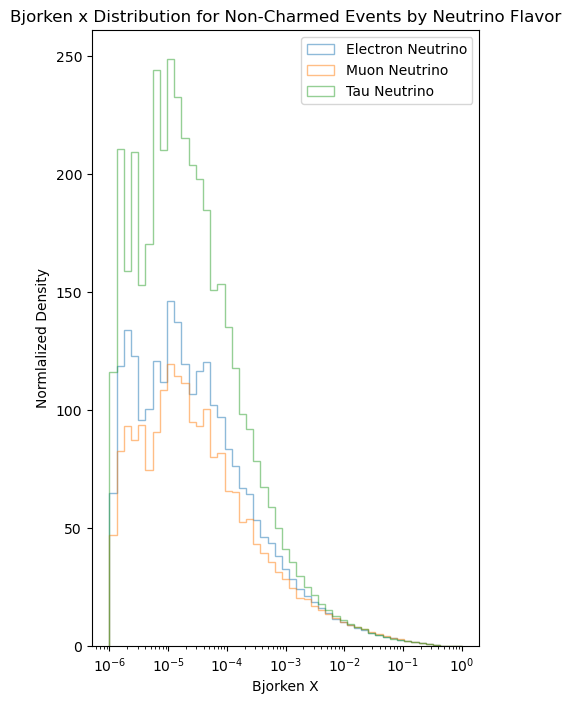

In [28]:
bins = np.logspace(-6, 0, 50)
plt.figure(figsize=(5,8))
plt.hist(bx_electron_neutrino, histtype = "step", alpha = 0.5, bins = bins, density = True, label = "Electron Neutrino")
plt.hist(bx_muon_neutrino, histtype = "step", alpha = 0.5, bins = bins, density = True, label = "Muon Neutrino")
plt.hist(bx_tau_neutrino, histtype = "step", alpha = 0.5, bins = bins, density = True, label = "Tau Neutrino")
plt.xscale("log")
plt.xlabel("Bjorken X")
plt.legend()
plt.ylabel("Normlalized Density")
plt.title("Bjorken x Distribution for Non-Charmed Events by Neutrino Flavor")
plt.show()

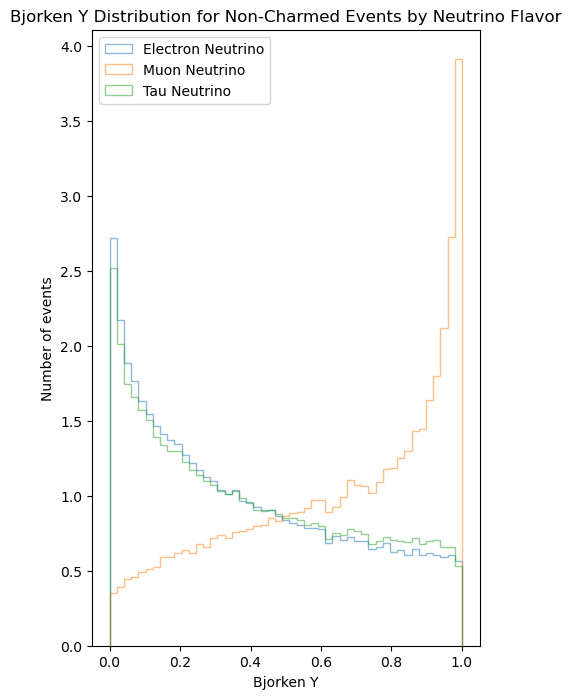

In [29]:
bins = np.linspace(0,1,50)
plt.figure(figsize=(5,8))
plt.hist(by_electron_neutrino, histtype = "step", alpha = 0.5, bins = bins, density = True, label = "Electron Neutrino")
plt.hist(by_cc_muon_neutrino, histtype = "step", alpha = 0.5, bins = bins, density = True, label = "Muon Neutrino")
plt.hist(by_tau_neutrino, histtype = "step", alpha = 0.5, bins = bins, density = True, label = "Tau Neutrino")
plt.xlabel("Bjorken Y")
plt.legend()
plt.ylabel("Number of events")
plt.title("Bjorken Y Distribution for Non-Charmed Events by Neutrino Flavor")
plt.show()

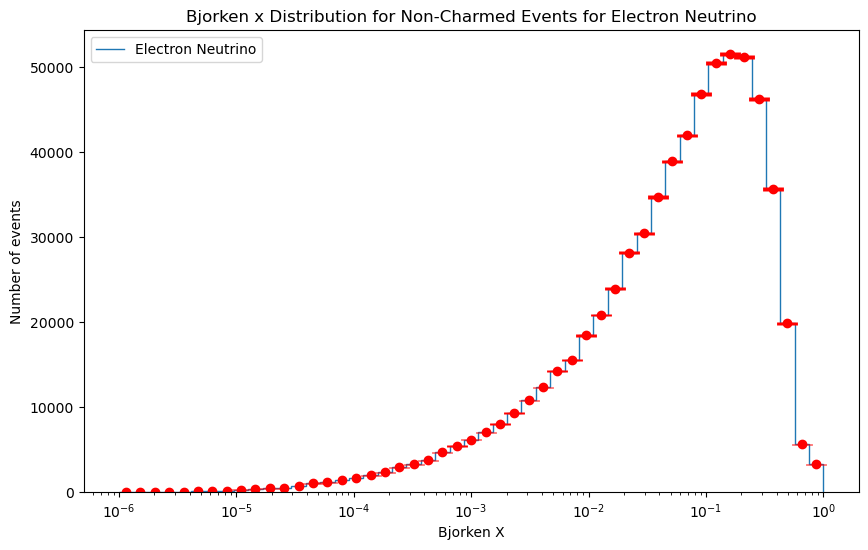

In [30]:
bins = np.logspace(-6, 0, 50)
counts, edges = np.histogram(bx_electron_neutrino, bins = bins)
centers = np.sqrt(edges[:-1]* edges[1:])
errors = np.sqrt(counts)
plt.figure(figsize=(10,6))
plt.stairs(counts, edges, label = "Electron Neutrino")
plt.errorbar(centers, counts, yerr = errors, fmt = "or", capsize = 2, elinewidth = 15)
plt.xscale("log")
plt.xlabel("Bjorken X")
plt.ylabel("Number of events")
plt.title("Bjorken x Distribution for Non-Charmed Events for Electron Neutrino")
plt.legend()
plt.show()

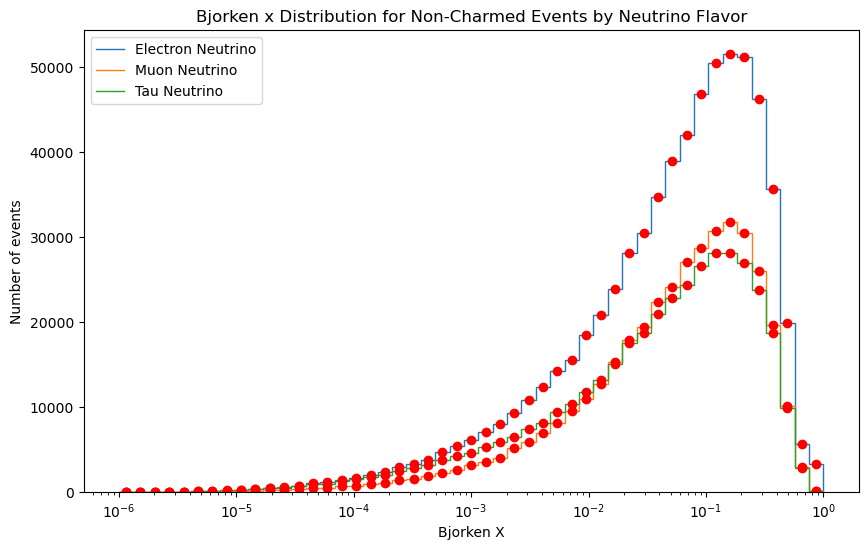

In [31]:
bins = np.logspace(-6, 0, 50)
counts_e, edges = np.histogram(bx_electron_neutrino, bins = bins)
centers_e = np.sqrt(edges[:-1]* edges[1:])
errors_e = np.sqrt(counts_e)

counts_m, edges = np.histogram(bx_muon_neutrino, bins = bins)
centers_m = np.sqrt(edges[:-1]* edges[1:])
errors_m = np.sqrt(counts_m)

counts_t, edges = np.histogram(bx_tau_neutrino, bins = bins)
centers_t = np.sqrt(edges[:-1]* edges[1:])
errors_t = np.sqrt(counts_t)

plt.figure(figsize=(10,6))

plt.stairs(counts_e, edges, label = "Electron Neutrino")
plt.stairs(counts_m, edges, label = "Muon Neutrino")
plt.stairs(counts_t, edges, label = "Tau Neutrino")

plt.errorbar(centers_e, counts_e, yerr = errors_e, fmt = "or", capsize = 2, elinewidth = 5)
plt.errorbar(centers_m, counts_m, yerr = errors_m, fmt = "or", capsize = 2, elinewidth = 5)
plt.errorbar(centers_t, counts_t, yerr = errors_t, fmt = "or", capsize = 2, elinewidth = 5)


plt.xscale("log")
plt.xlabel("Bjorken X")
plt.ylabel("Number of events")
plt.title("Bjorken x Distribution for Non-Charmed Events by Neutrino Flavor")
plt.legend()
plt.show()

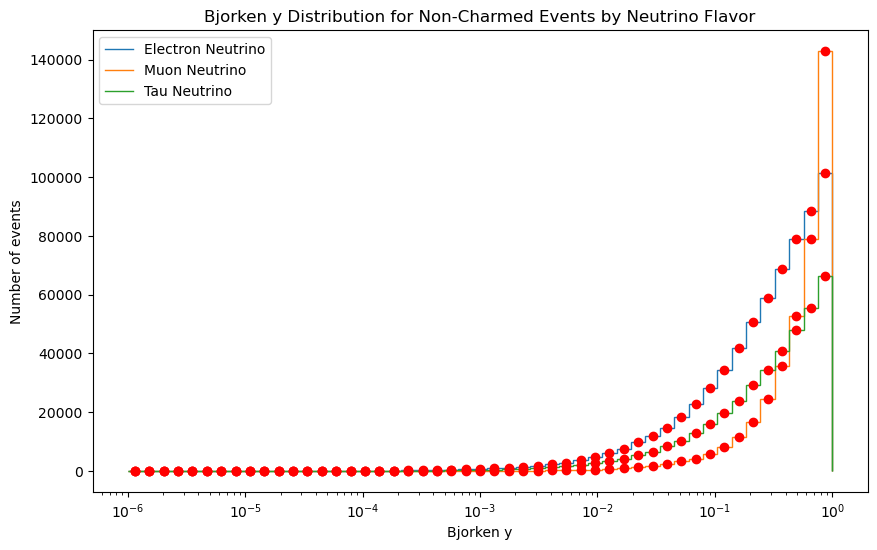

In [32]:
bins = np.logspace(-6, 0, 50)
counts_e, edges = np.histogram(by_electron_neutrino, bins = bins)
centers_e = np.sqrt(edges[:-1]* edges[1:])
errors_e = np.sqrt(counts)

counts_m, edges = np.histogram(by_muon_neutrino, bins = bins)
centers_m = np.sqrt(edges[:-1]* edges[1:])
errors_m = np.sqrt(counts)

counts_t, edges = np.histogram(by_tau_neutrino, bins = bins)
centers_t = np.sqrt(edges[:-1]* edges[1:])
errors_t = np.sqrt(counts)

plt.figure(figsize=(10,6))

plt.stairs(counts_e, edges, label = "Electron Neutrino")
plt.stairs(counts_m, edges, label = "Muon Neutrino")
plt.stairs(counts_t, edges, label = "Tau Neutrino")

plt.errorbar(centers_e, counts_e, yerr = errors_e, fmt = "or", capsize = 2, elinewidth = 5)
plt.errorbar(centers_m, counts_m, yerr = errors_m, fmt = "or", capsize = 2, elinewidth = 5)
plt.errorbar(centers_t, counts_t, yerr = errors_t, fmt = "or", capsize = 2, elinewidth = 5)


plt.xscale("log")
plt.xlabel("Bjorken y")
plt.ylabel("Number of events")
plt.title("Bjorken y Distribution for Non-Charmed Events by Neutrino Flavor")
plt.legend()
plt.show()

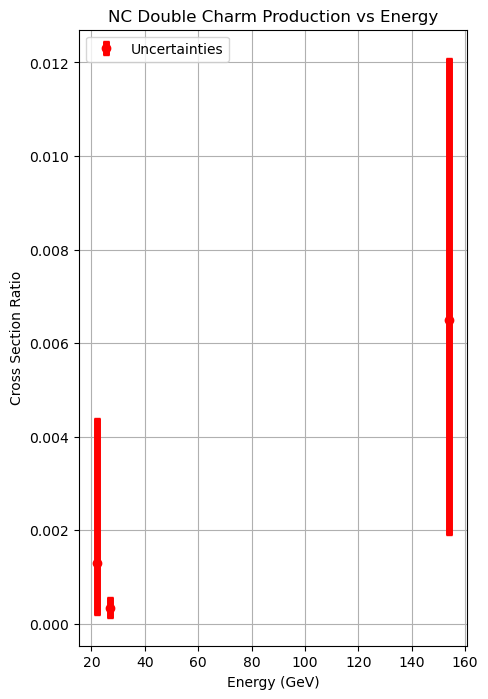

In [33]:
E = np.array([22, 27, 154])
CS = np.array([0.0013, 0.00035, 0.0065])

yerr_l = np.array([0.0011, 0.000218, 0.0046])
yerr_u = np.array([0.0031, 0.000218, 0.0056])

yerr = [yerr_l, yerr_u]

plt.figure(figsize = (5,8))
plt.errorbar(E, CS, yerr = yerr, fmt = "or", capsize = 2, elinewidth = 5, label='Uncertainties')

plt.xlabel("Energy (GeV)")
plt.ylabel("Cross Section Ratio")
plt.title("NC Double Charm Production vs Energy")

plt.grid("True")
plt.legend()
plt.show()

In [37]:
#weights = df["weight"]
#print(weights)

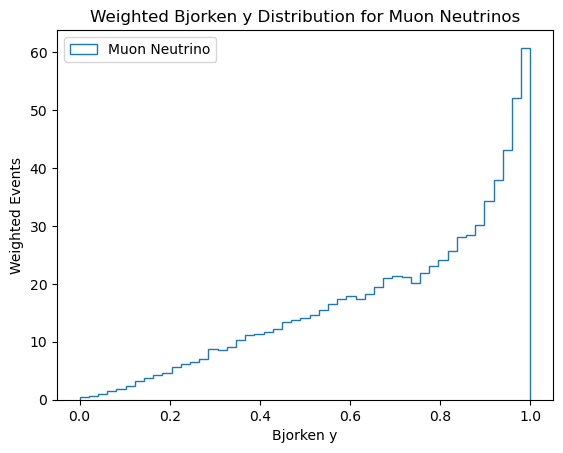

In [49]:
weight_muon_neu = df.loc[muon_neutrino, "weight"]
bins = np.linspace(0, 1, 50)

plt.hist(by_muon_neutrino, bins=bins, weights=weight_muon_neu, histtype="step", label="Muon Neutrino")

plt.xlabel("Bjorken y")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken y Distribution for Muon Neutrinos")
plt.legend()
plt.show()

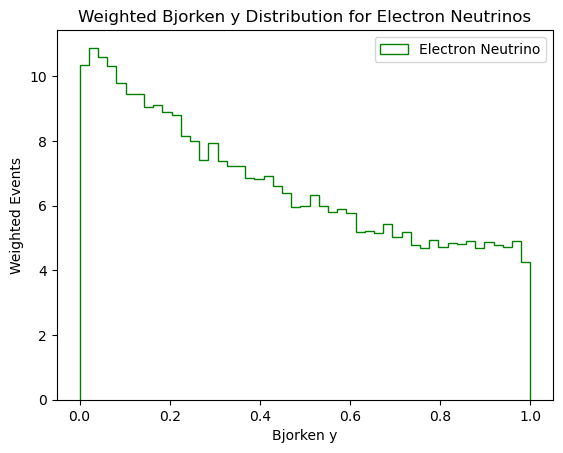

In [51]:
weight_electron_neu = df.loc[electron_neutrino, "weight"]
bins = np.linspace(0, 1, 50)

plt.hist(by_electron_neutrino, bins=bins, weights=weight_electron_neu, histtype="step", color = "green", label="Electron Neutrino")

plt.xlabel("Bjorken y")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken y Distribution for Electron Neutrinos")
plt.legend()
plt.show()

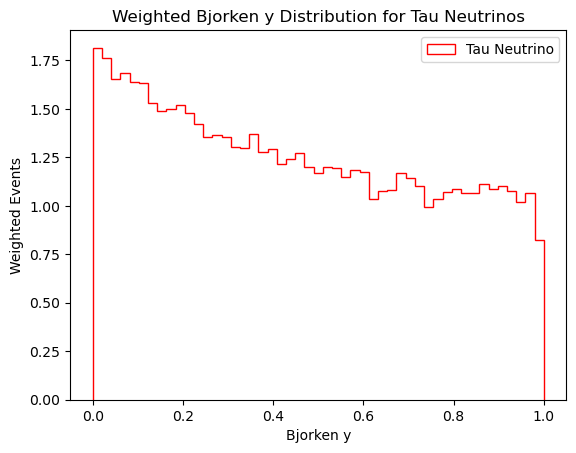

In [50]:
weight_tau_neu = df.loc[tau_neutrino, "weight"]
bins = np.linspace(0, 1, 50)

plt.hist(by_tau_neutrino, bins=bins, weights=weight_tau_neu, histtype="step", color = "red", label="Tau Neutrino")

plt.xlabel("Bjorken y")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken y Distribution for Tau Neutrinos")
plt.legend()
plt.show()

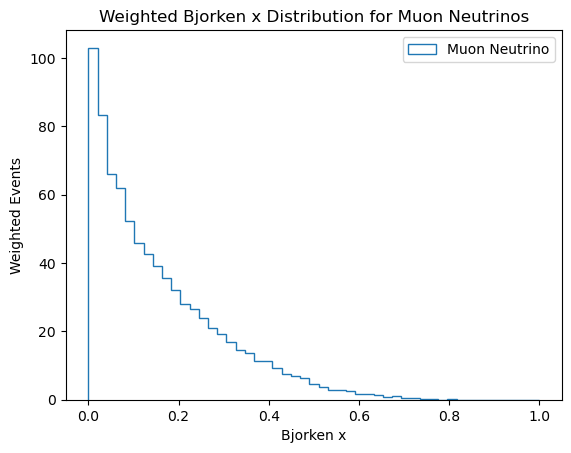

In [52]:
weight_muon_neu = df.loc[muon_neutrino, "weight"]
bins = np.linspace(0, 1, 50)

plt.hist(bx_muon_neutrino, bins=bins, weights=weight_muon_neu, histtype="step", label="Muon Neutrino")

plt.xlabel("Bjorken x")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken x Distribution for Muon Neutrinos")
plt.legend()
plt.show()

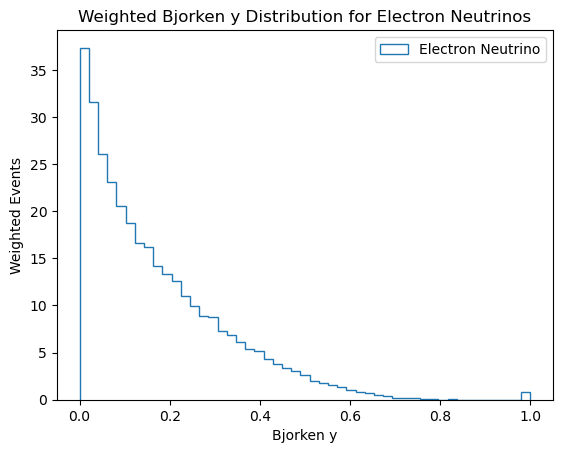

In [54]:
weight_electron_neu = df.loc[electron_neutrino, "weight"]
bins = np.linspace(0, 1, 50)

plt.hist(bx_electron_neutrino, bins=bins, weights=weight_electron_neu, histtype="step", label="Electron Neutrino")

plt.xlabel("Bjorken y")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken y Distribution for Electron Neutrinos")
plt.legend()
plt.show()

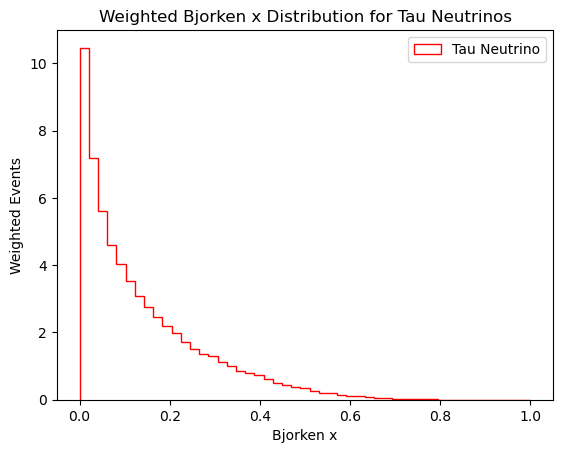

In [55]:
weight_tau_neu = df.loc[tau_neutrino, "weight"]
bins = np.linspace(0, 1, 50)

plt.hist(bx_tau_neutrino, bins=bins, weights=weight_tau_neu, histtype="step", color = "red", label="Tau Neutrino")

plt.xlabel("Bjorken x")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken x Distribution for Tau Neutrinos")
plt.legend()
plt.show()

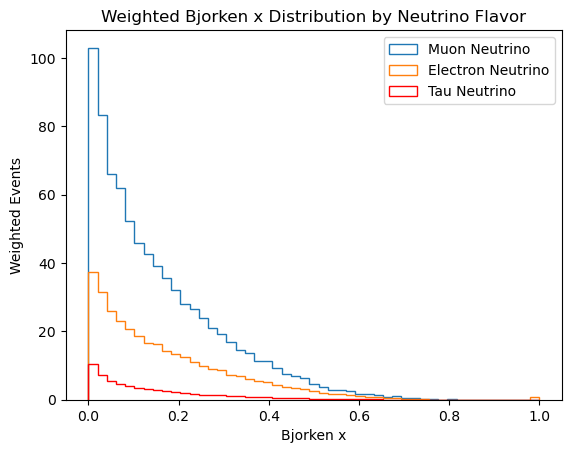

In [58]:
bins = np.linspace(0, 1, 50)

plt.hist(bx_muon_neutrino, bins=bins, weights=weight_muon_neu, histtype="step", label="Muon Neutrino")
plt.hist(bx_electron_neutrino, bins=bins, weights=weight_electron_neu, histtype="step", label="Electron Neutrino")
plt.hist(bx_tau_neutrino, bins=bins, weights=weight_tau_neu, histtype="step", color = "red", label="Tau Neutrino")

plt.xlabel("Bjorken x")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken x Distribution by Neutrino Flavor")
plt.legend()
plt.show()

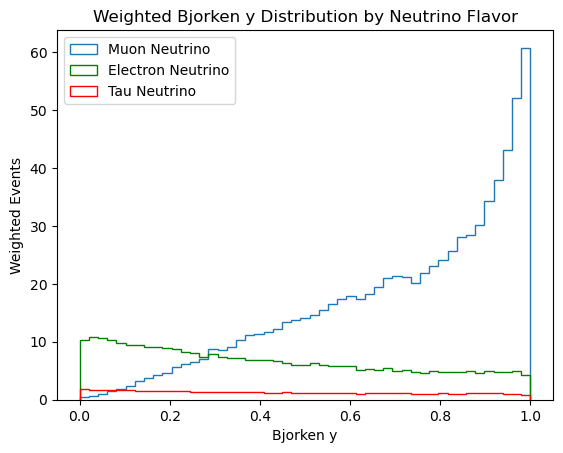

In [59]:
bins = np.linspace(0, 1, 50)

plt.hist(by_muon_neutrino, bins=bins, weights=weight_muon_neu, histtype="step", label="Muon Neutrino")
plt.hist(by_electron_neutrino, bins=bins, weights=weight_electron_neu, histtype="step", color = "green", label="Electron Neutrino")
plt.hist(by_tau_neutrino, bins=bins, weights=weight_tau_neu, histtype="step", color = "red", label="Tau Neutrino")

plt.xlabel("Bjorken y")
plt.ylabel("Weighted Events")
plt.title("Weighted Bjorken y Distribution by Neutrino Flavor")
plt.legend()
plt.show()

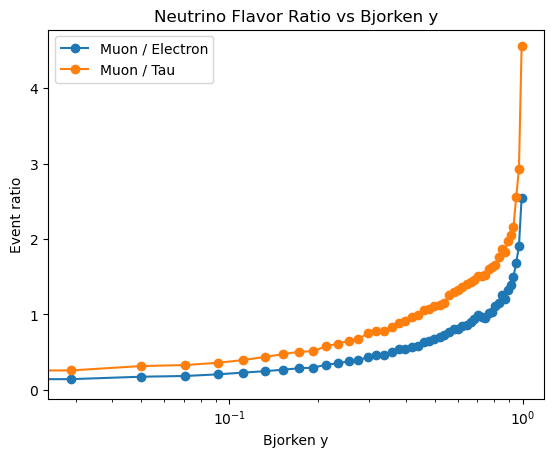

In [67]:
counts_muon, edges = np.histogram(by_muon_neutrino, bins=bins)
counts_ele, edges = np.histogram(by_electron_neutrino, bins=bins)
counts_tau, edges = np.histogram(by_tau_neutrino, bins=bins)

centers = np.sqrt(edges[:-1] * edges[1:])

ratio_muon_ele = counts_muon / counts_ele
ratio_muon_tau = counts_muon / counts_tau

plt.plot(centers, ratio_muon_ele, marker="o", label="Muon / Electron")
plt.plot(centers, ratio_muon_tau, marker="o", label="Muon / Tau")

plt.xscale("log")
plt.xlabel("Bjorken y")
plt.ylabel("Event ratio")
plt.title("Neutrino Flavor Ratio vs Bjorken y")
plt.legend()
plt.show()